# **Modelo SARIMA — Seasonal ARIMA**


O SARIMA (Seasonal Autoregressive Integrated Moving Average) é uma extensão do ARIMA que adiciona componentes sazonais para lidar com padrões que se repetem em intervalos regulares (diário, semanal, mensal, anual, etc.).

A notação completa é:

 ## **$SARIMA(p, d, q) \times (P, D, Q)_s$**

*  $(p,d,q)$ → parte não sazonal **(igual ao ARIMA) (veja exemplo anterior)**
* $(P,D,Q)_s$  → parte sazonal
* $s$ → período sazonal (ex.: 12 para meses, 7 para dias da semana, 4 para trimestres)




## **Estrutura da Componente Sazonal:$(P, D, Q)_s$**

Enquanto os termos **$(p, d, q)$** analisam a relação entre períodos consecutivos (ex.: mês a mês: $t$ com $t-1$), os termos sazonais **$(P, D, Q)_s$** analisam a relação entre ciclos sazonais completos (ex.: ano a ano: $t$ com $t-s$).1.

* **Período Sazonal ($s$)** Indica a frequência com que o padrão se repete ao longo do tempo:
   * $s = 12$ para dados mensais com padrão anual.
   * $s = 7$ para dados diários com padrão semanal.
   * $s = 4$ para dados trimestrais.

 * **Autorregressão Sazonal ($P$)** Mede a influência direta do mesmo período no ciclo anterior sobre o valor atual.
   * **Exemplo** para $P = 1$ e $s = 12$: A venda de dezembro deste ano depende diretamente da venda de dezembro do ano passado ($Y_{t-12}$).
   
   * **Fórmula simplificada:**
   $$Y_t = \Phi_1 Y_{t-s} + \epsilon_t$$.
   
  *  **Diferenciação Sazonal ($D$)** Mede o número de vezes que a série precisa ser subtraída do seu valor no ciclo anterior para remover a sazonalidade e estabilizar a média sazonal.

     * **Exemplo** para $D = 1$ e $s = 12$: Subtrai-se o valor atual pelo valor de 12 meses atrás:$$\Delta_s Y_t = Y_t - Y_{t-s}$$
  
     * **Quando usar**: Se o gráfico temporal mostrar um padrão em "onda" ou picos recorrentes na mesma época a cada ano.
  
  * **Média Móvel Sazonal ($Q$)** Mede o impacto dos erros de previsão do ciclo sazonal anterior sobre o valor atual.
     * **Exemplo** para $Q = 1$ e $s = 12$: O erro cometido na previsão de dezembro do ano passado ($\epsilon_{t-12}$) é usado para ajustar a previsão de dezembro deste ano.
     * **Fórmula simplificada:** $$Y_t = \epsilon_t + \Theta_1 \epsilon_{t-s}$$

# **Importando as bibliotecas**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from  matplotlib.pylab import rcParams
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
rcParams['figure.figsize'] =15,7

## **Série Air Passengers**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Carregar AirPassengers
df_air = sm.datasets.get_rdataset("AirPassengers").data
serie_ar_passengers = pd.Series(df_air['value'].values, index=pd.date_range('1949-01-01', periods=len(df_air), freq='MS'))

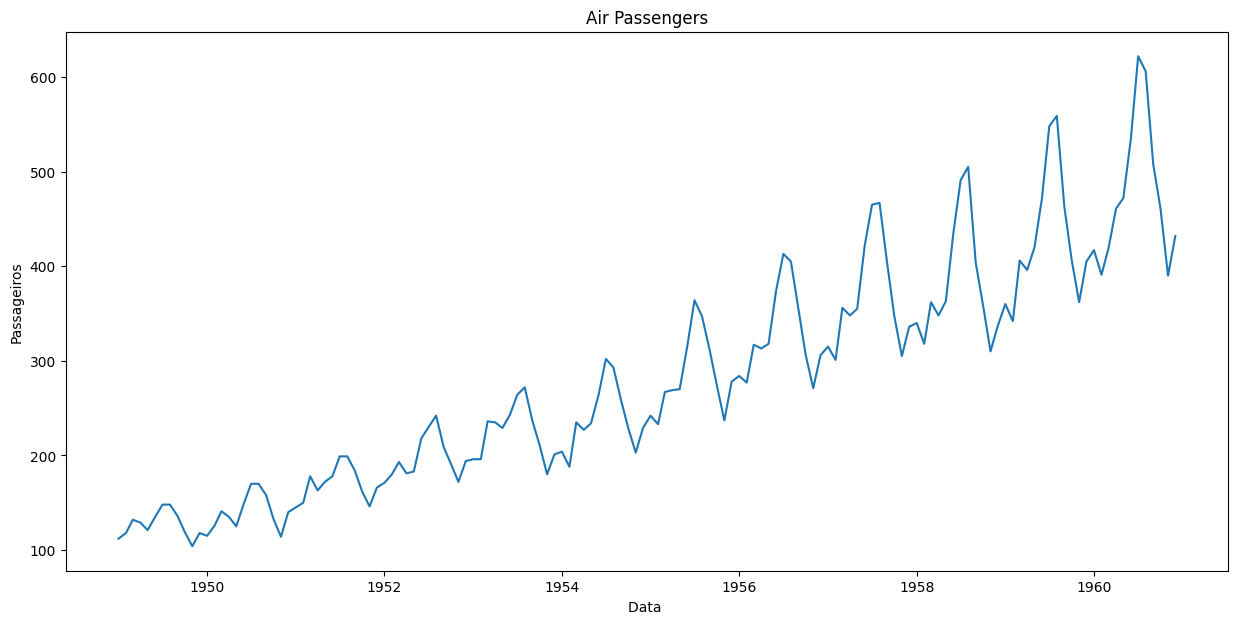

In [ ]:
plt.plot(serie_ar_passengers)
plt.title('Air Passengers')
plt.xlabel('Data ')
plt.ylabel('Passageiros')
plt.show()


# **Estudo da Série temporal**

Nesta seção será realizdo o estudo da série temporal, onde serão avaliados:

* Decomposição

* Normalidade da série.
  * Teste de Shapiro-Wilk
  * Grafico QQ_plot
  * Histograma
* Estacionariadade (Teste KPSS)
* Funções de auto correlação (ACF e PACF)

### **Decomposicao**

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposicao = seasonal_decompose(serie_ar_passengers, model='additive')

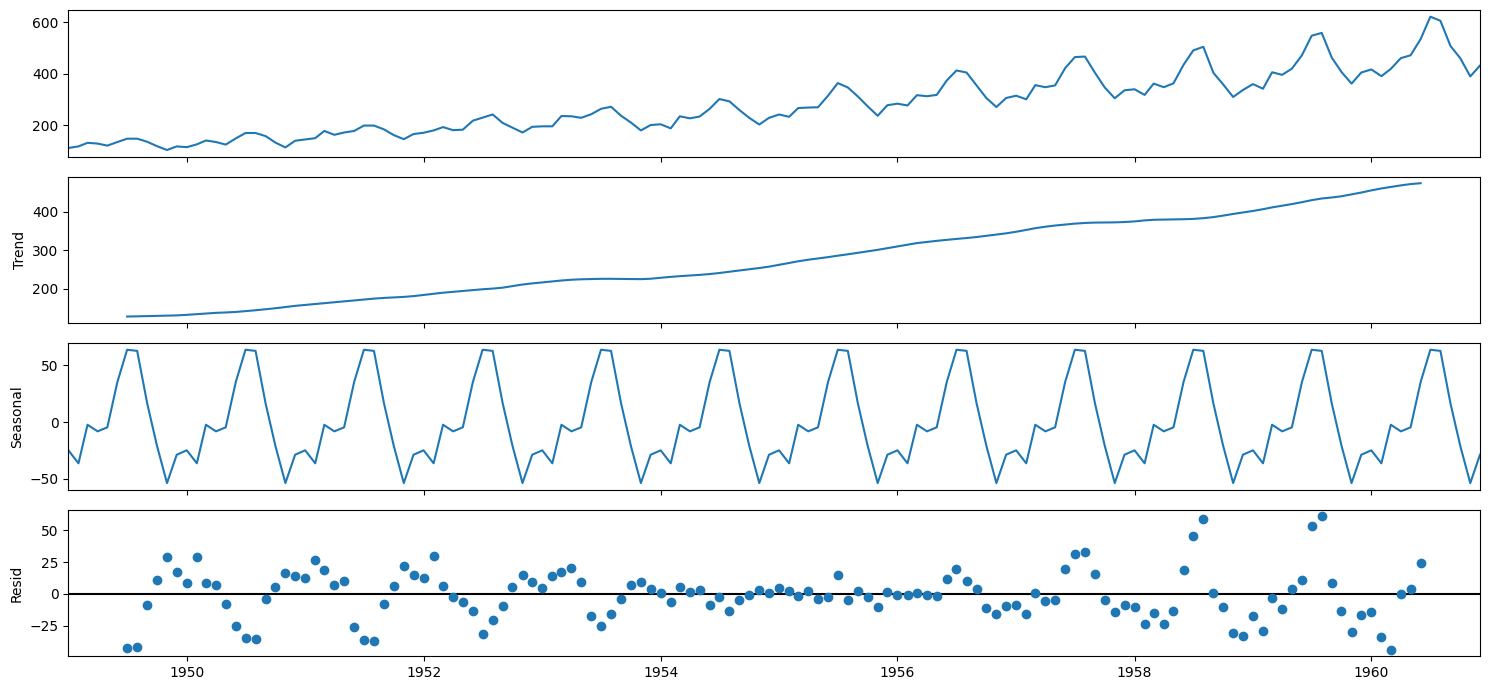

In [ ]:
decomposicao.plot()
plt.show()

## **Normalidade da série.**

### **Hipóteses do Teste de Shapiro-Wilk**


O teste avalia duas hipóteses concorrentes:
* **Hipótese Nula ($H_0$):** Os dados seguem uma distribuição normal.
* **Hipótese Alternativa ($H_1$):** Os dados não seguem uma distribuição normal.

**Como Interpretar o P-Valor (p-value)**

* **Se $p \ge 0,05$:** Não há evidências para rejeitar $H_0$. Conclui-se que os resíduos do modelo são aproximadamente normais (modelo validado quanto à normalidade).
* **Se $p < 0,05$:** Rejeita-se $H_0$. Os resíduos não seguem uma distribuição normal, indicando possíveis problemas no modelo (como presenças de outliers ou heterocedasticidade

In [ ]:
import scipy.stats as stats

e,p_valor =stats.shapiro(serie_ar_passengers)
print('Estatistica de teste = %.3f, p-valor = %.3f' % (e,p_valor))

Estatistica de teste = 0.952, p-valor = 0.000


In [ ]:
if p_valor >= 0.05:
  print('Não há evidências para rejeitar a hipótese nula. Os dados seguem uma distribuição normal.')
else:
  print('Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.')

Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.


### **QQ_plot**

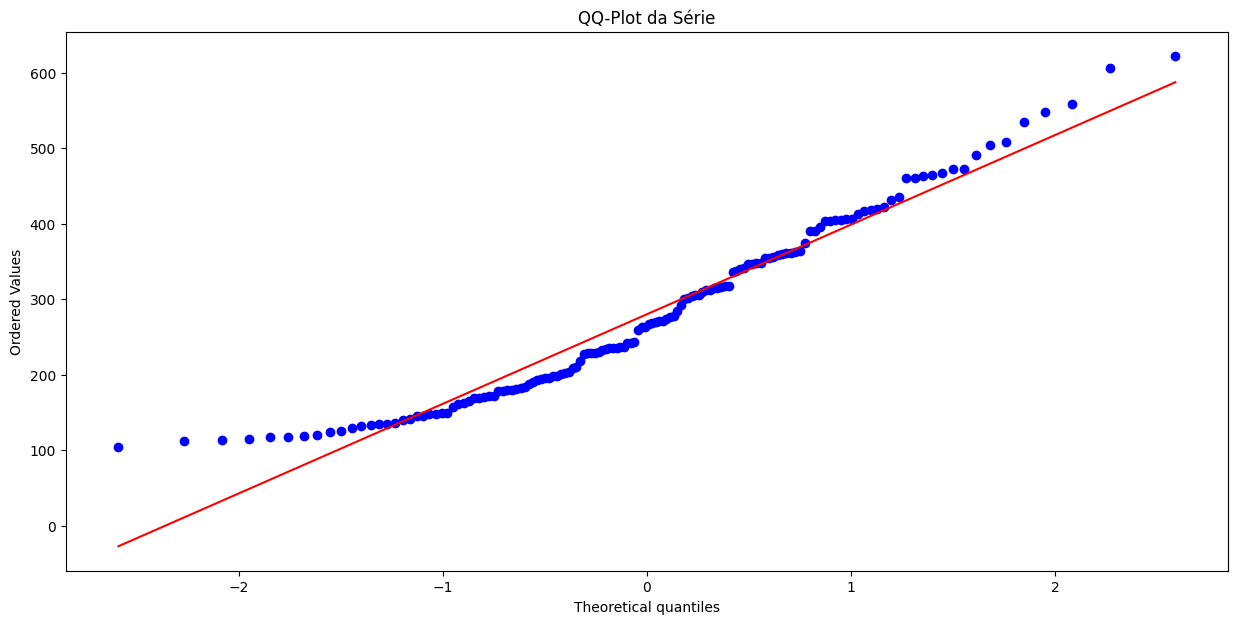

In [ ]:
import scipy.stats as stats
stats.probplot(serie_ar_passengers, dist='norm', plot=plt)
plt.title('QQ-Plot da Série')
plt.show()

### **Histrograma da série**

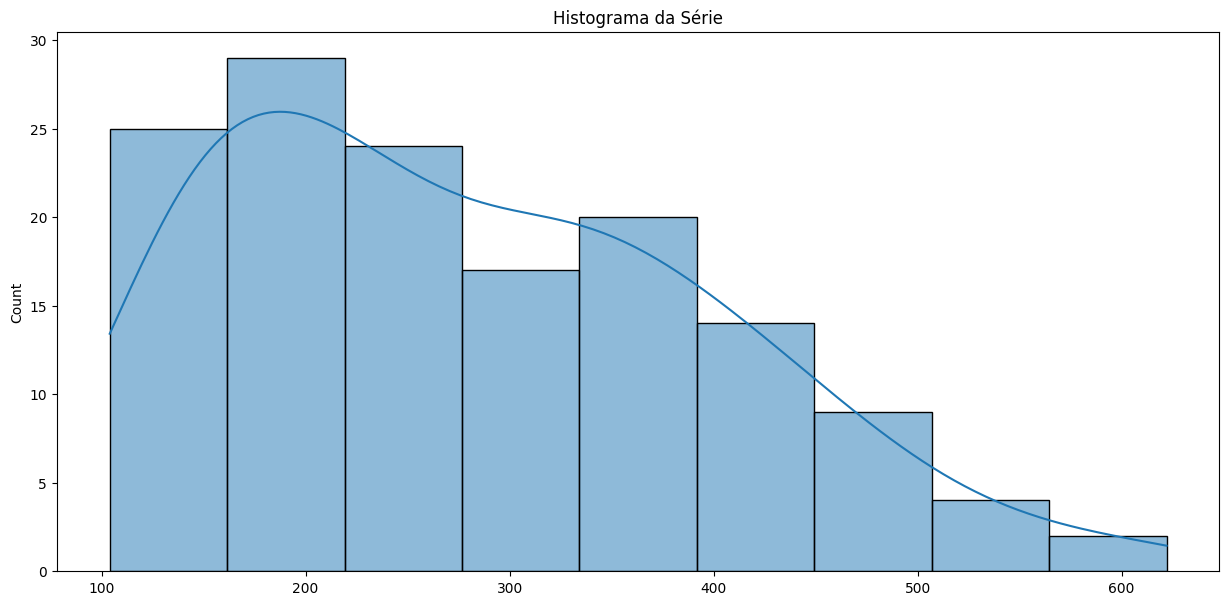

In [ ]:
import seaborn as sns
sns.histplot(serie_ar_passengers, kde=True)
plt.title('Histograma da Série')
plt.show()

## **Estacionaridade da série -Modelo Autoregressivo**

O teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin) é um teste estatístico utilizado em séries temporais para verificar se os dados são estacionários em torno de uma média ou de uma tendência determinística.

**Como o Teste Funciona**
* **Hipótese Nula (H₀):** A série temporal é estacionária (em nível ou em tendência).
* **Hipótese Alternativa (H₁):** A série temporal não é estacionária (possui raiz unitária

**Interpretação dos Resultados**
* **p-valor > 0,05** (ou estatística menor que o valor crítico): Você não rejeita a hipótese nula. Os dados indicam que a série é estacionária.
* **p-valor ≤ 0,05** (ou estatística maior que o valor crítico): Você rejeita a hipótese nula. Há fortes evidências de que a série não é estacionária

In [ ]:
import statsmodels.tsa.stattools

In [ ]:
result_kpss = statsmodels.tsa.stattools.kpss(serie_ar_passengers)
print('Estatistica de teste = %.3f, p-valor = %.3f' % (result_kpss[0], result_kpss[1]))

Estatistica de teste = 1.651, p-valor = 0.010


/tmp/ipykernel_939/1065753695.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  result_kpss = statsmodels.tsa.stattools.kpss(serie_ar_passengers)
/tmp/ipykernel_939/1065753695.py:1: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_kpss = statsmodels.tsa.stattools.kpss(serie_ar_passengers)


In [ ]:
if p_valor > 0.05:
    print('A série é estacionária')
else:
    print('A série não é estacionária')

A série não é estacionária


##  **Estudo da autocorrelaçao (ACF e PACF)**

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

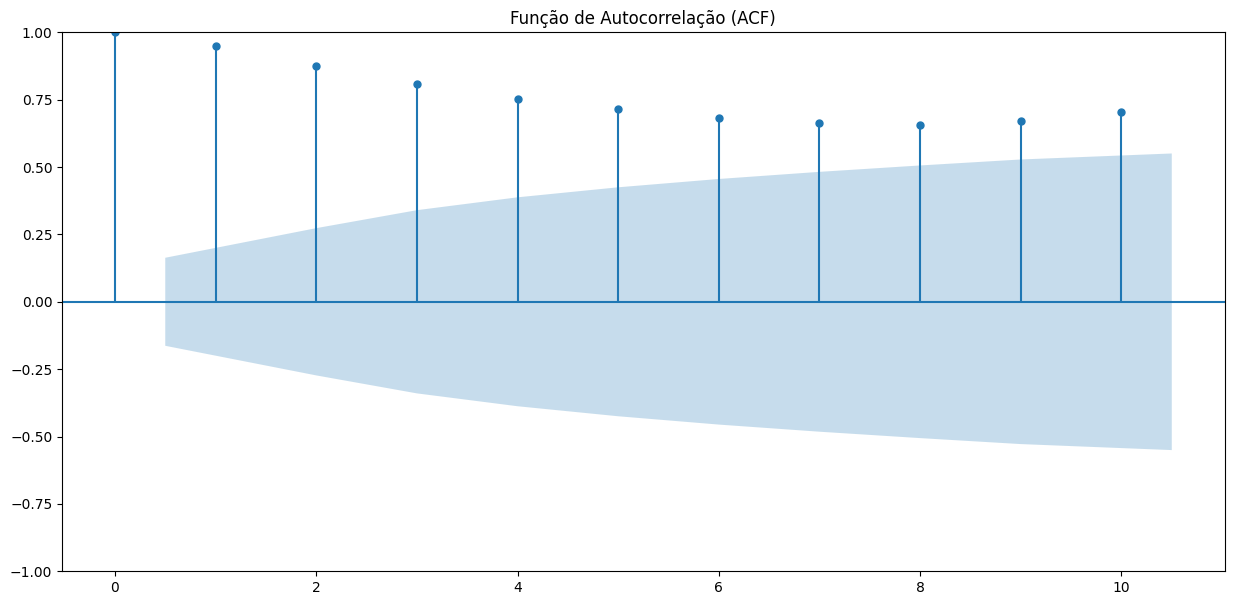

In [ ]:
plot_acf(serie_ar_passengers,lags=10, color='#1f77b4', title='Função de Autocorrelação (ACF)')
plt.show()

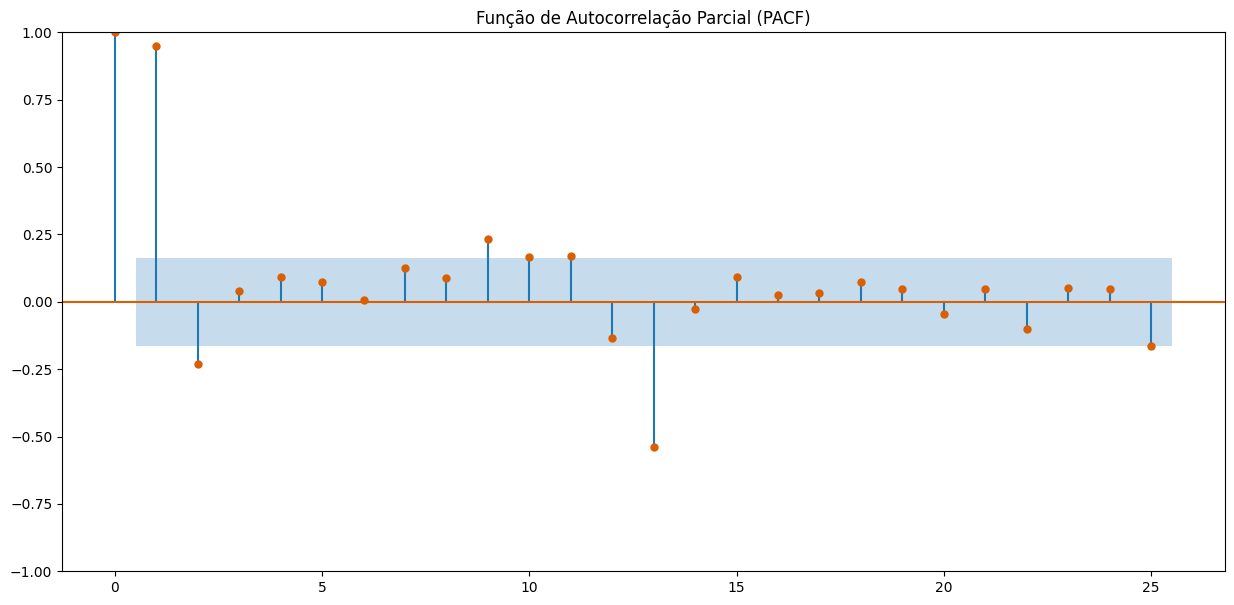

In [ ]:
plot_pacf(serie_ar_passengers, lags=25, color='#d95f02', title='Função de Autocorrelação Parcial (PACF)')
plt.show()

# **Implementação do modelo  SARIMA**

* Definição do modelo
* Estudo do resíduo
* Aplicação do modelo.

## **Definição do modelo SARIMA**

In [ ]:
modelo_sarima = SARIMAX(serie_ar_passengers, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))

In [ ]:
modelo_sarima_result = modelo_sarima.fit()

In [ ]:
print(modelo_sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Fri, 18 Sep 2026   AIC                           1022.299
Time:                                    00:02:41   BIC                           1036.675
Sample:                                01-01-1949   HQIC                          1028.140
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1272      0.356     -0.358      0.721      -0.825       0.570
ma.L1         -0.2148      0.325   

## **Estudo do resíduo**

In [ ]:
residuos_modelo_sarima = modelo_sarima_result.resid

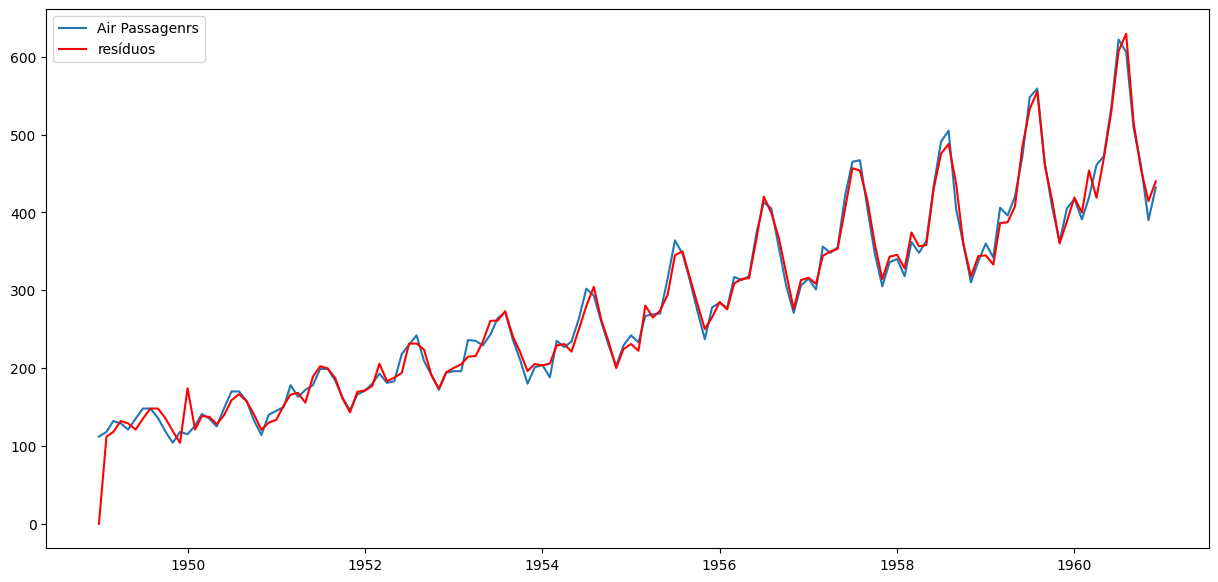

In [ ]:
plt.plot(serie_ar_passengers, label  ="Air Passagenrs")
plt.plot(serie_ar_passengers-residuos_modelo_sarima, color ='red', label ="resíduos")
plt.legend(loc = 'best')
plt.show()

###  **Normalidade do resíduo**

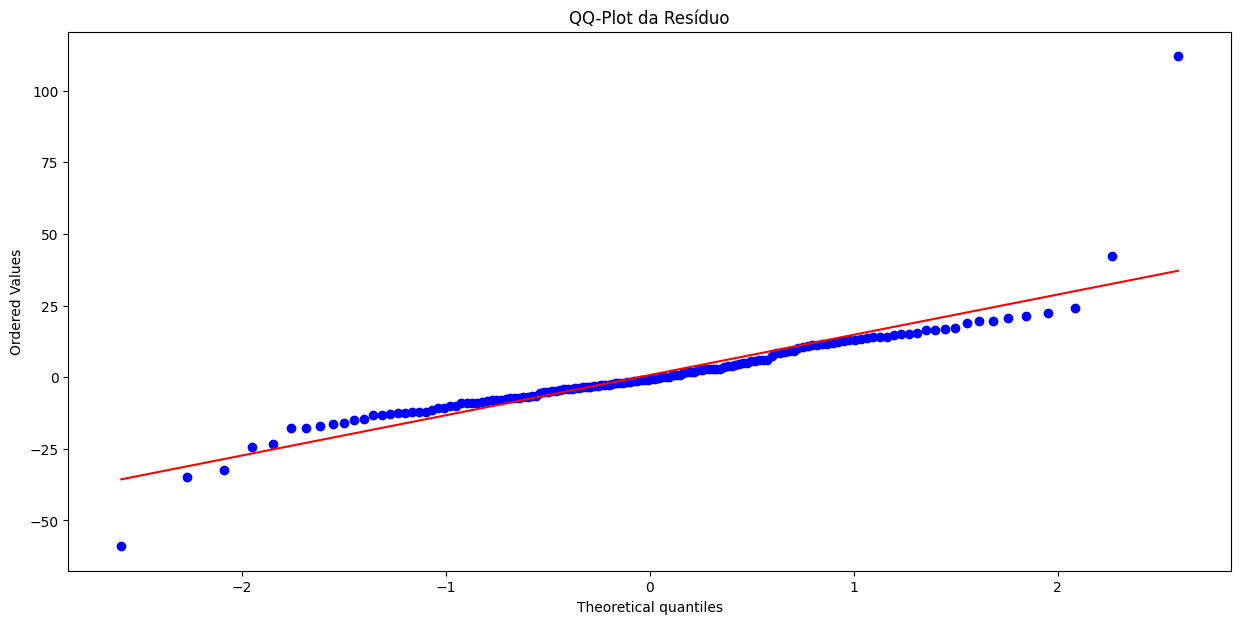

In [ ]:
import scipy.stats as stats
stats.probplot(residuos_modelo_sarima, dist='norm', plot=plt)
plt.title('QQ-Plot da Resíduo')
plt.show()

In [ ]:
e,p_valor =stats.shapiro(residuos_modelo_sarima)
print('Estatistica de teste = %.3f, p-valor = %.3f' % (e,p_valor))

Estatistica de teste = 0.814, p-valor = 0.000


In [ ]:
if p_valor >= 0.05:
  print('Não há evidências para rejeitar a hipótese nula. Os dados seguem uma distribuição normal.')
else:
  print('Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.')

Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.


### **Autocorrelação dos resíduos**

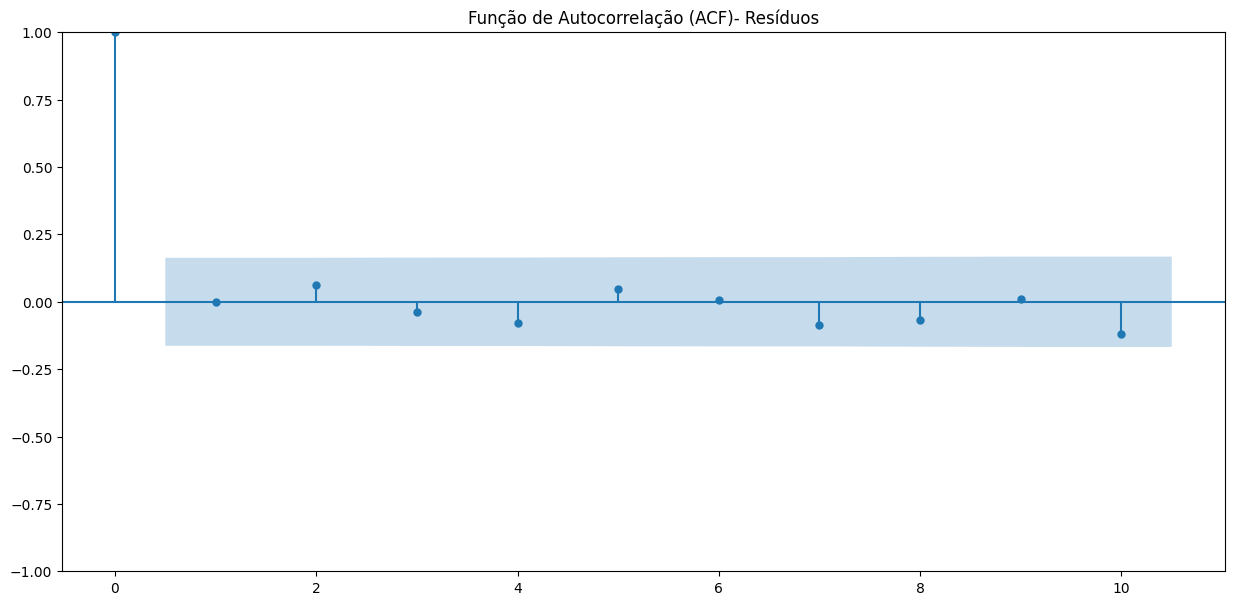

In [ ]:
plot_acf(residuos_modelo_sarima,lags=10, color='#1f77b4', title='Função de Autocorrelação (ACF)- Resíduos')
plt.show()


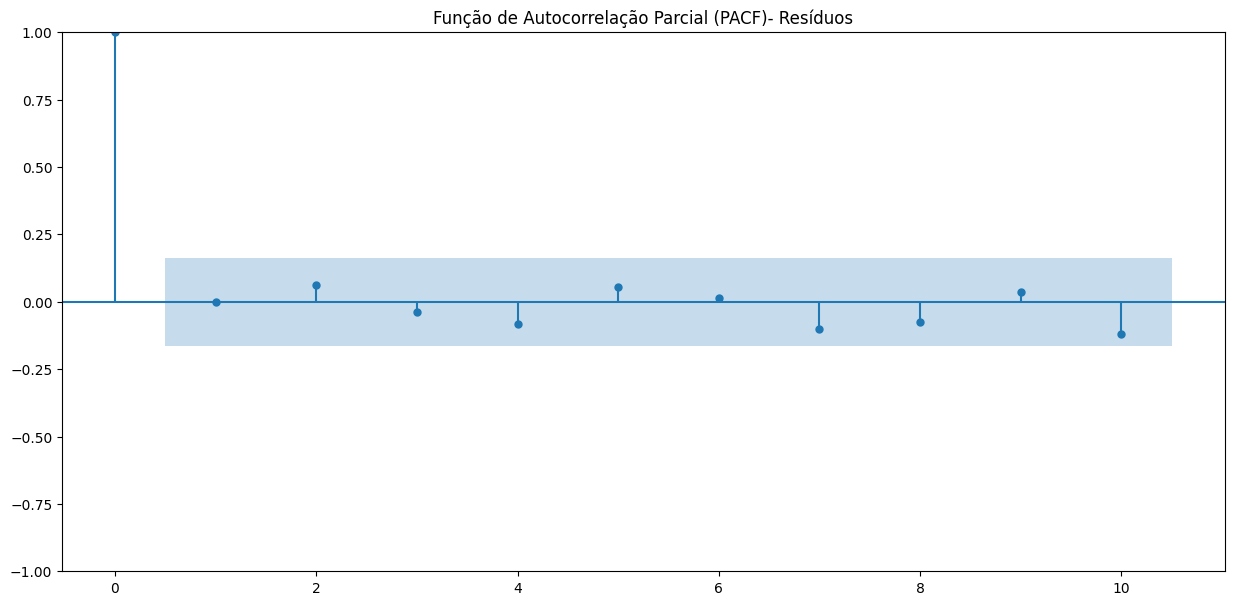

In [ ]:
plot_pacf(residuos_modelo_sarima,lags=10, color='#1f77b4', title='Função de Autocorrelação Parcial (PACF)- Resíduos')
plt.show()

# **Aplicando o modelo**

In [ ]:
modelo_sarima_result.fittedvalues

,0
1949-01-01,0.000000
1949-02-01,111.997241
1949-03-01,118.000055
1949-04-01,131.999303
1949-05-01,129.000236
...,...
1960-08-01,629.391169
1960-09-01,515.007391
1960-10-01,455.437586
1960-11-01,414.455489


In [ ]:
previsao_sarima = modelo_sarima_result.forecast(10)

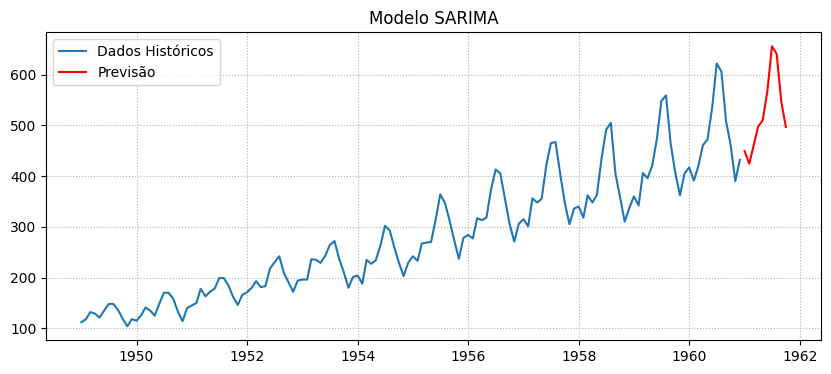

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(serie_ar_passengers, label='Dados Históricos')
plt.plot(previsao_sarima, color='red', label='Previsão')
plt.title('Modelo SARIMA')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

## **Criando os intervalor de confiança para as previsões**

In [ ]:
previsao_modelo_sarima = modelo_sarima_result.get_forecast(steps=36).summary_frame()

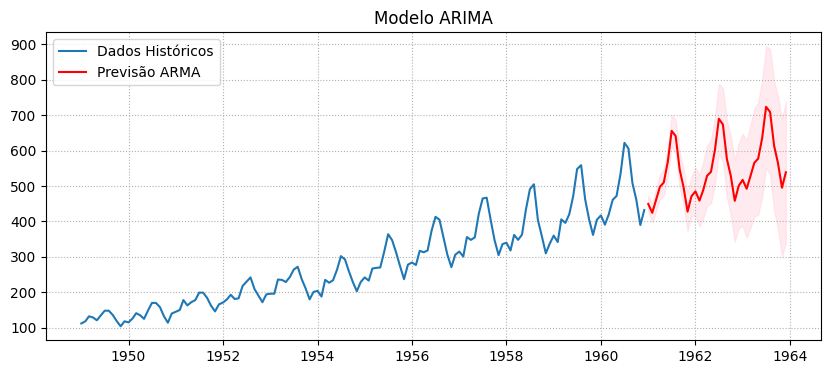

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(serie_ar_passengers, label='Dados Históricos')
plt.plot(previsao_modelo_sarima['mean'], color='red', label='Previsão ARMA')
plt.fill_between(previsao_modelo_sarima.index,previsao_modelo_sarima['mean_ci_lower'], previsao_modelo_sarima['mean_ci_upper'], color='pink', alpha=0.3)
plt.title('Modelo ARIMA')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()